In [ ]:
# Proyecto 1 - Deep Learning
# Grupo 5: Luis Puicón, César Padilla, Kevin Oré, Valeria Pérez
# Docente: Nadia Valderrama
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


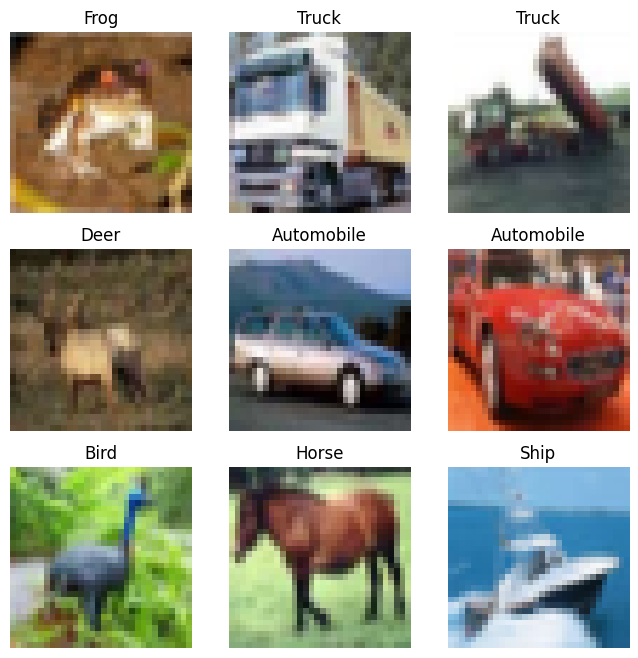

In [ ]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model_base = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_base = model_base.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


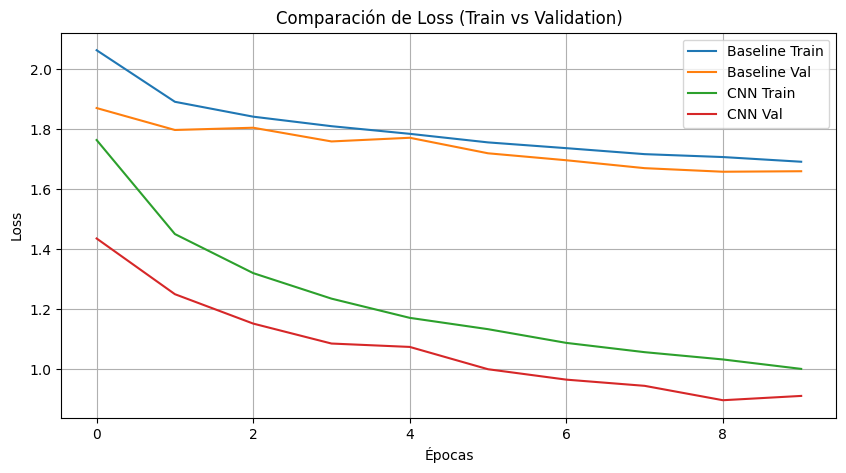

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_base.history['loss'], label='Baseline Train')
plt.plot(history_base.history['val_loss'], label='Baseline Val')

plt.plot(history_cnn.history['loss'], label='CNN Train')
plt.plot(history_cnn.history['val_loss'], label='CNN Val')

plt.title("Comparación de Loss (Train vs Validation)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

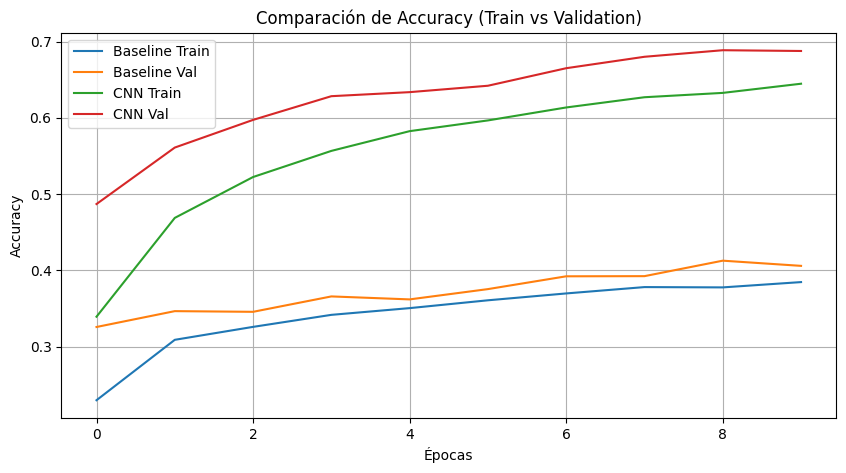

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_base.history['accuracy'], label='Baseline Train')
plt.plot(history_base.history['val_accuracy'], label='Baseline Val')

plt.plot(history_cnn.history['accuracy'], label='CNN Train')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val')

plt.title("Comparación de Accuracy (Train vs Validation)")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
accuracy_baseline, loss_baseline = model_base.evaluate(x_test, y_test, verbose=0)
accuracy_cnn, loss_cnn = model_cnn.evaluate(x_test, y_test, verbose=0)

print("Baseline - Accuracy:", accuracy_baseline)
print("Baseline - Loss:", loss_baseline)

print("CNN - Accuracy:", accuracy_cnn)
print("CNN - Loss:", loss_cnn)

Baseline - Accuracy: 1.63800048828125
Baseline - Loss: 0.4219000041484833
CNN - Accuracy: 0.9201661944389343
CNN - Loss: 0.6777999997138977


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


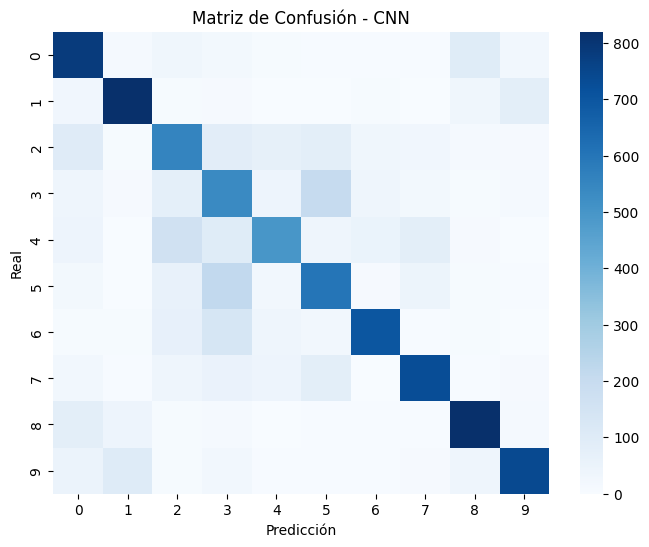

In [ ]:
y_pred = model_cnn.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Matriz de Confusión - CNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

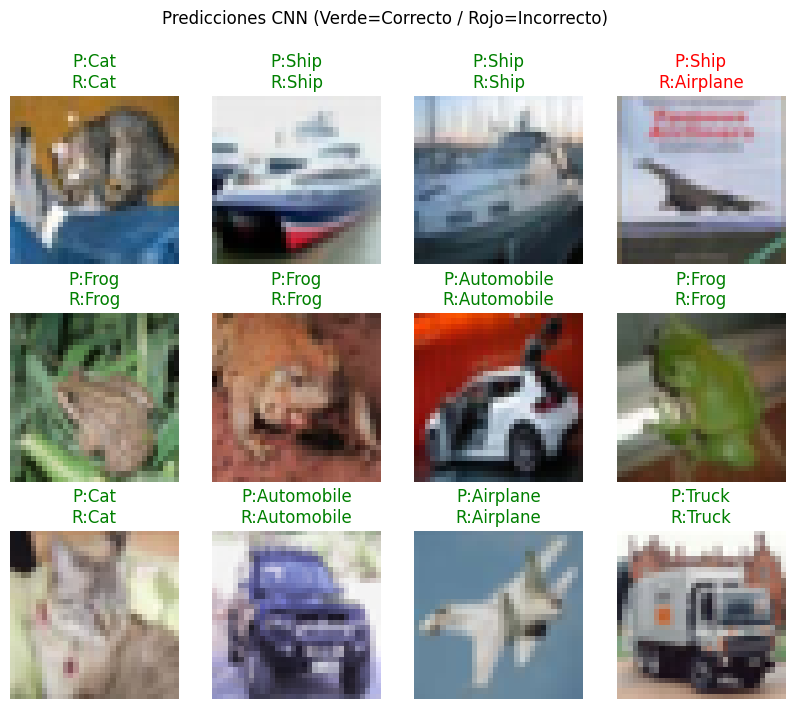

In [ ]:
plt.figure(figsize=(10,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[i])
    pred = class_names[y_pred_classes[i]]
    real = class_names[y_true[i]]
    color = "green" if pred == real else "red"
    plt.title(f"P:{pred}\nR:{real}", color=color)
    plt.axis("off")
plt.suptitle("Predicciones CNN (Verde=Correcto / Rojo=Incorrecto)")
plt.show()